In [50]:
import pandas as pd
import numpy as np
import os
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

In [51]:
df = pd.read_csv(
    "../data/integrated/master_dataset_featured.csv"
)

print(df.shape)

(52920, 74)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52920 entries, 0 to 52919
Data columns (total 74 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   request_id                52920 non-null  object 
 1   resident_id               52920 non-null  object 
 2   apartment_id              52920 non-null  object 
 3   asset_id                  52920 non-null  object 
 4   category                  52920 non-null  object 
 5   subcategory               52920 non-null  object 
 6   complaint_text            52920 non-null  object 
 7   request_date              52920 non-null  object 
 8   priority                  52920 non-null  object 
 9   status                    52920 non-null  object 
 10  assigned_technician_id    52920 non-null  object 
 11  resolved_date             52920 non-null  object 
 12  resolution_time_hours     52920 non-null  float64
 13  dataset_version           52920 non-null  object 
 14  tower_

In [17]:
df["priority"].value_counts()

priority
high         21035
medium       11190
low          10410
emergency    10285
Name: count, dtype: int64

In [52]:
sample_size = min(
    3000,
    len(df)
)

df = df.sample(
    n=sample_size,
    random_state=42
)

print(df.shape)

(3000, 74)


In [59]:
features = [

    "complaint_text",

    "category",

    "subcategory",

    "season_flag",

    "complaint_hour",

    "asset_category"

]

target = "priority"

In [54]:
clf_df = df[
    features + [target]
].dropna()

print(clf_df.shape)

(3000, 7)


In [56]:
X = clf_df[features]

y = clf_df[target]

In [57]:
print(y.value_counts())

priority
high         1186
medium        663
emergency     613
low           538
Name: count, dtype: int64


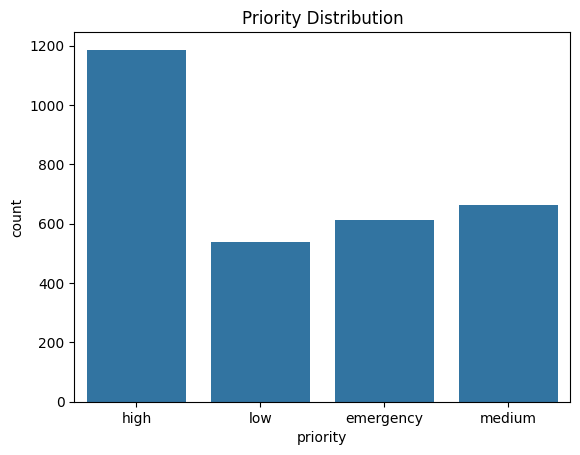

In [58]:
sns.countplot(
    x=y
)

plt.title(
    "Priority Distribution"
)

plt.show()

In [61]:
text_feature = "complaint_text"

cat_features = [

    "category",

    "subcategory",

    "season_flag",

    "asset_category"

]

num_features = [

    "complaint_hour"
]

In [62]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "text",

            TfidfVectorizer(

                max_features=500,

                stop_words="english",

                min_df=5

            ),

            text_feature

        ),

        (

            "cat",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            cat_features

        ),

        (

            "num",

            "passthrough",

            num_features

        )

    ]

)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    stratify=y,

    random_state=42

)

In [65]:
priority_model = Pipeline([

    (

        "prep",

        preprocessor

    ),

    (

        "rf",

        RandomForestClassifier(

            n_estimators=50,

            max_depth=10,

            class_weight="balanced",

            random_state=42

        )

    )

])

In [66]:
priority_model.fit(
    X_train,
    y_train
)

,steps,"[('prep', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
priority_pred = priority_model.predict(
    X_test
)

In [68]:
acc = accuracy_score(
    y_test,
    priority_pred
)

f1 = f1_score(
    y_test,
    priority_pred,
    average="weighted"
)

print("Accuracy:",acc)
print("F1:",f1)

Accuracy: 0.49877173091458804
F1: 0.4853028829210333


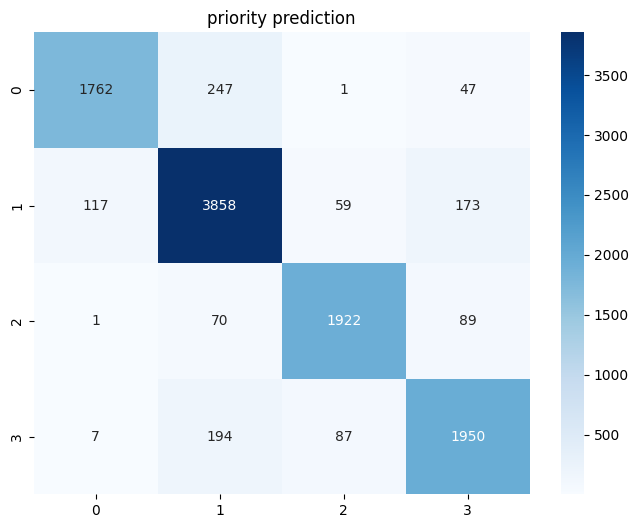

In [ ]:
print(

    classification_report(

        y_test,

        priority_pred

    )

)

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=500
)

X_text = tfidf.fit_transform(
    model_df["complaint_text"]
)

In [49]:
smote = SMOTE(
    random_state=42
)

X_smote, y_smote = smote.fit_resample(
    X_text,
    y
)

ValueError: Found input variables with inconsistent numbers of samples: [3000, 52920]